# MATD3 Safe PoC Compare

Train a locked-parameter MATD3 baseline and a MATD3_SAFE_POC run, then compare both against an MPC perfect-reference rollout.


In [25]:
from __future__ import annotations

import gc
import importlib
import json
import math
import os
import shutil
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "configs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "configs").exists():
    raise RuntimeError("Could not locate the project root.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from configs import compose_experiment_config
from scripts.checkpoints import build_training_run_paths
from scripts.utils.forecast_shared_preset import get_managed_lstm_forecast_controls
from scripts.utils.project_paths import get_checkpoint_root, project_root
from scripts.utils.train_mainline_launcher import run_external_train_mainline

_deployments = importlib.import_module("envs.grid.deployments")
_deployments = importlib.reload(_deployments)
resolve_fixed_battery_spec = _deployments.resolve_fixed_battery_spec

_builder = importlib.import_module("scripts.builder")
_builder = importlib.reload(_builder)

_experiment_notebook_utils = importlib.import_module("scripts.utils.experiment_notebook_utils")
_experiment_notebook_utils = importlib.reload(_experiment_notebook_utils)
resolve_madrl_model_root = _experiment_notebook_utils.resolve_madrl_model_root

_grid_notebook_workflow = importlib.import_module("scripts.utils.grid_notebook_workflow")
_grid_notebook_workflow = importlib.reload(_grid_notebook_workflow)

apply_notebook_experiment_settings = _grid_notebook_workflow.apply_notebook_experiment_settings
collect_madrl_rollout = _grid_notebook_workflow.collect_madrl_rollout
collect_mpc_rollout = _grid_notebook_workflow.collect_mpc_rollout
compare_rollout_metrics = _grid_notebook_workflow.compare_rollout_metrics
plot_power_balance_bars = _grid_notebook_workflow.plot_power_balance_bars
plot_rollout_comparison_dashboard = _grid_notebook_workflow.plot_rollout_comparison_dashboard
plot_rollout_dashboard = _grid_notebook_workflow.plot_rollout_dashboard


In [ ]:
PROJECT_ROOT = project_root()
DATA_DIR = PROJECT_ROOT / "data"
CHECKPOINT_ROOT = get_checkpoint_root(PROJECT_ROOT)

COMPARE_TAG = "c16e100l192g"
MPC_REFERENCE_ENABLED = True
TRAIN_ENV_NAME = "MADRL_ESS"
FORECAST_AUTO_TRAIN_MISSING = False

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

DEVICE_REQUEST = "cuda"
SEED = 0
PREDICTION_MODE = "normal"
FORCE_RETRAIN_BASELINE = False
RUN_BASELINE_IF_MISSING = True
FORCE_RETRAIN_SAFE = False
RUN_SAFE_TRAINING = True
BASELINE_MODEL_ROOT = None
SAFE_MODEL_ROOT = None
SAFE_PROJECTOR_MODE = "joint_linearized"
SAFE_PROJECTION_ITERS = 6 if SAFE_PROJECTOR_MODE == "joint_linearized" else 3

FORECAST_CONTROLS = get_managed_lstm_forecast_controls(
    artifact_root=PROJECT_ROOT / "artifacts" / "forecast" / "lstm",
    auto_train_missing=FORECAST_AUTO_TRAIN_MISSING,
)

DATA_CONTROLS = {
    "prediction_mode": PREDICTION_MODE,
    "test_start_date": 20200801,
    "test_end_date": 20200805,
    "agent_profiles": ["SFH12", "SFH14", "SFH16", "SFH18", "SFH20"],
    "agent_bus_ids": [10, 6, 12, 4, 2],
    "load_scale": [5.0, 5.0, 5.0, 5.0, 5.0],
    "pv_scale": [6.0, 6.0, 6.0, 6.0, 6.0],
    "future_horizon": int(FORECAST_CONTROLS["future_horizon"]),
    "train_year": 2019,
    "test_year": 2020,
}

BATTERY_CONTROLS = {
    "battery_capacity": [25.0, 25.0, 25.0, 25.0, 25.0],
    "max_charge_rate": 0.4,
    "efficiency": 0.95,
    "init_soc": 0.5,
    "soc_min": 0.05,
    "soc_max": 0.95,
    "soc_target": 0.5,
}

TRAIN_NUM_ENVS = 16
TRAIN_EPISODE_STEPS = 2 * 96
TRAIN_EPISODES_PER_ENV = 100

RUNTIME_CONTROLS = {
    "pin_memory": True,
    "non_blocking_transfers": True,
    "enable_amp": True,
    "amp_dtype": "bfloat16",
    "enable_compile": True,
    "compile_mode": "reduce-overhead",
    "compile_fullgraph": False,
    "compile_dynamic": False,
    "matmul_precision": "high",
}

TRAIN_CONTROLS = {
    "profile": "gpu_fast",
    "model_family": "mlp",
    "num_envs": TRAIN_NUM_ENVS,
    "vec_env_type": "subproc",
    "train_episodes": TRAIN_NUM_ENVS * TRAIN_EPISODES_PER_ENV,
    "max_train_steps": None,
    "batch_size": 4096,
    "buffer_size": 400000,
    "update_interval": 1,
    "updates_per_step": 1,
    "policy_update_freq": 2,
    "actor_lr": 1e-4,
    "critic_lr": 1e-4,
    "noise_std_init": 0.35,
    "noise_std_min": 0.05,
    "use_noise_decay": True,
    "show_progress": True,
    "progress_postfix_interval": 20,
    "progress_write_interval_seconds": 10.0,
}

COMMON_EXPERIMENT_CONTROLS = {
    "seed": SEED,
    "runtime_mode": "performance",
    "device_request": DEVICE_REQUEST,
    "require_cuda": True,
    "forecast_controls": dict(FORECAST_CONTROLS),
    "runtime_controls": dict(RUNTIME_CONTROLS),
}

BASELINE_EXPERIMENT_NAME = f"cmp_{COMPARE_TAG}"
SAFE_EXPERIMENT_NAME = f"scmp_{COMPARE_TAG}"

BASELINE_EXPERIMENT_CONTROLS = {
    **COMMON_EXPERIMENT_CONTROLS,
    "algorithm": "MATD3",
}

SAFE_EXPERIMENT_CONTROLS = {
    **COMMON_EXPERIMENT_CONTROLS,
    "algorithm": "MATD3_SAFE_POC",
    "safety_controls": {
        "enabled": True,
        "projector_mode": SAFE_PROJECTOR_MODE,
        "projection_iters": SAFE_PROJECTION_ITERS,
        "voltage_margin_pu": 0.005,
        "line_margin_pct": 5.0,
        "trafo_margin_pct": 5.0,
        "record_diagnostics": True,
    },
}

BASELINE_CHECKPOINT_CONTROLS = {
    "checkpoint_root": str(CHECKPOINT_ROOT),
    "experiment_name": BASELINE_EXPERIMENT_NAME,
}

SAFE_CHECKPOINT_CONTROLS = {
    "checkpoint_root": str(CHECKPOINT_ROOT),
    "experiment_name": SAFE_EXPERIMENT_NAME,
}

BASELINE_LABEL = f"MATD3 baseline [{PREDICTION_MODE}]"
SAFE_LABEL = f"MATD3_SAFE_POC [{PREDICTION_MODE}/{SAFE_PROJECTOR_MODE}]"
MPC_PERFECT_LABEL = "MPC perfect [oracle_eval]"
MPC_NORMAL_LABEL = "MPC normal [forecast_eval]"


In [27]:
total_episodes = int(TRAIN_CONTROLS["train_episodes"])
steps_per_env = int(TRAIN_EPISODE_STEPS * TRAIN_EPISODES_PER_ENV)
total_env_steps = int(steps_per_env * TRAIN_NUM_ENVS)
parallel_rollout_iterations = int(total_env_steps // TRAIN_NUM_ENVS)
warmup_parallel_iters = int(math.ceil(TRAIN_CONTROLS["batch_size"] / TRAIN_NUM_ENVS))
update_triggers = sum(
    1
    for interaction_step in range(1, parallel_rollout_iterations + 1)
    if interaction_step >= warmup_parallel_iters
    and interaction_step % int(TRAIN_CONTROLS["update_interval"]) == 0
)
approx_critic_updates = int(update_triggers * TRAIN_CONTROLS["updates_per_step"])
approx_actor_updates = int(approx_critic_updates // TRAIN_CONTROLS["policy_update_freq"])

baseline_run_paths = build_training_run_paths(
    CHECKPOINT_ROOT,
    algorithm="MATD3",
    prediction_mode=PREDICTION_MODE,
    experiment_name=BASELINE_EXPERIMENT_NAME,
    train_episodes=TRAIN_CONTROLS["train_episodes"],
    max_train_steps=TRAIN_CONTROLS["max_train_steps"],
)
safe_run_paths = build_training_run_paths(
    CHECKPOINT_ROOT,
    algorithm="MATD3_SAFE_POC",
    prediction_mode=PREDICTION_MODE,
    experiment_name=SAFE_EXPERIMENT_NAME,
    train_episodes=TRAIN_CONTROLS["train_episodes"],
    max_train_steps=TRAIN_CONTROLS["max_train_steps"],
)
baseline_meta_chars = len(str(Path(baseline_run_paths["meta_dir"]) / "experiment_controls.json"))
safe_meta_chars = len(str(Path(safe_run_paths["meta_dir"]) / "experiment_controls.json"))

budget_summary = pd.DataFrame([
    {
        "episode_steps": TRAIN_EPISODE_STEPS,
        "episodes_per_env": TRAIN_EPISODES_PER_ENV,
        "num_envs": TRAIN_NUM_ENVS,
        "total_episodes": total_episodes,
        "steps_per_env": steps_per_env,
        "total_env_steps": total_env_steps,
        "parallel_rollout_iterations": parallel_rollout_iterations,
        "approx_critic_updates": approx_critic_updates,
        "approx_actor_updates": approx_actor_updates,
        "warmup_parallel_iters": warmup_parallel_iters,
        "baseline_meta_path_chars": baseline_meta_chars,
        "safe_meta_path_chars": safe_meta_chars,
        "safe_projection_iters": SAFE_PROJECTION_ITERS,
    }
])

runtime_summary = pd.DataFrame([
    {
        "train_env_name": TRAIN_ENV_NAME,
        "device_request": DEVICE_REQUEST,
        "require_cuda": COMMON_EXPERIMENT_CONTROLS["require_cuda"],
        "runtime_mode": COMMON_EXPERIMENT_CONTROLS["runtime_mode"],
        "force_retrain_baseline": FORCE_RETRAIN_BASELINE,
        "train_baseline_if_missing": RUN_BASELINE_IF_MISSING,
        "force_retrain_safe": FORCE_RETRAIN_SAFE,
        "train_safe_if_missing": RUN_SAFE_TRAINING,
        "amp_enabled_requested": RUNTIME_CONTROLS["enable_amp"],
        "amp_dtype": RUNTIME_CONTROLS["amp_dtype"],
        "compile_enabled_requested": RUNTIME_CONTROLS["enable_compile"],
        "compile_mode": RUNTIME_CONTROLS["compile_mode"],
        "pin_memory": RUNTIME_CONTROLS["pin_memory"],
        "non_blocking_transfers": RUNTIME_CONTROLS["non_blocking_transfers"],
        "cuda_alloc_conf": os.environ.get("PYTORCH_CUDA_ALLOC_CONF"),
        "compare_tag": COMPARE_TAG,
        "safe_projector_mode": SAFE_PROJECTOR_MODE,
        "forecast_artifact_root": FORECAST_CONTROLS["artifact_root"],
        "forecast_auto_train_missing": FORECAST_AUTO_TRAIN_MISSING,
        "forecast_override_signals": ",".join(sorted(FORECAST_CONTROLS["signal_training_overrides"])),
    }
])

battery_capacity_kwh_each, battery_c_rate, p_max_kw_each = resolve_fixed_battery_spec(
    BATTERY_CONTROLS["battery_capacity"],
    BATTERY_CONTROLS["max_charge_rate"],
    n_agents=len(DATA_CONTROLS["agent_profiles"]),
)
assert len(battery_capacity_kwh_each) == len(DATA_CONTROLS["agent_profiles"])
assert len(p_max_kw_each) == len(DATA_CONTROLS["agent_profiles"])
battery_summary = pd.DataFrame([
    {
        "battery_capacity_kwh_each": battery_capacity_kwh_each,
        "battery_c_rate": battery_c_rate,
        "p_max_kw_each": p_max_kw_each,
    }
])

display(budget_summary)
display(runtime_summary)
display(battery_summary)


,episode_steps,episodes_per_env,num_envs,total_episodes,steps_per_env,total_env_steps,parallel_rollout_iterations,approx_critic_updates,approx_actor_updates,warmup_parallel_iters,baseline_meta_path_chars,safe_meta_path_chars,safe_projection_iters
0,192,100,16,1600,19200,307200,19200,18945,9472,256,191,211,6


,train_env_name,device_request,require_cuda,runtime_mode,force_retrain_baseline,train_baseline_if_missing,force_retrain_safe,train_safe_if_missing,amp_enabled_requested,amp_dtype,compile_enabled_requested,compile_mode,pin_memory,non_blocking_transfers,cuda_alloc_conf,compare_tag,safe_projector_mode
0,MADRL_ESS,cuda,True,performance,True,True,True,True,True,bfloat16,True,reduce-overhead,True,True,expandable_segments:True,c16e100l192g,joint_linearized


In [28]:
def build_eval_cfg(algorithm: str):
    cfg = compose_experiment_config(
        profile=str(TRAIN_CONTROLS["profile"]),
        algorithm=algorithm,
        model_family=str(TRAIN_CONTROLS["model_family"]),
        vec_env_type=str(TRAIN_CONTROLS["vec_env_type"]),
        data_dir=DATA_DIR,
        device=DEVICE_REQUEST,
        runtime_mode=str(COMMON_EXPERIMENT_CONTROLS["runtime_mode"]),
        seed=SEED,
        require_cuda=bool(COMMON_EXPERIMENT_CONTROLS["require_cuda"]),
    )
    for field_name, field_value in RUNTIME_CONTROLS.items():
        setattr(cfg.runtime, field_name, field_value)
    if algorithm == "MATD3_SAFE_POC":
        cfg.safety.enabled = True
        cfg.safety.projector_mode = SAFE_PROJECTOR_MODE
        cfg.safety.projection_iters = SAFE_PROJECTION_ITERS
    if int(cfg.env.episode_limit) != int(TRAIN_EPISODE_STEPS):
        raise ValueError(
            f"Expected env episode_limit={TRAIN_EPISODE_STEPS}, got {cfg.env.episode_limit}. "
            "Update the notebook constants or the environment config so they match."
        )
    apply_notebook_experiment_settings(
        cfg,
        prediction_mode=PREDICTION_MODE,
        test_start_date=DATA_CONTROLS["test_start_date"],
        test_end_date=DATA_CONTROLS["test_end_date"],
        agent_profiles=list(DATA_CONTROLS["agent_profiles"]),
        agent_bus_ids=list(DATA_CONTROLS["agent_bus_ids"]),
        load_scale=list(DATA_CONTROLS["load_scale"]),
        pv_scale=list(DATA_CONTROLS["pv_scale"]),
        battery_controls=dict(BATTERY_CONTROLS),
        forecast_controls=dict(FORECAST_CONTROLS),
        future_horizon=int(DATA_CONTROLS["future_horizon"]),
        train_year=int(DATA_CONTROLS["train_year"]),
        test_year=int(DATA_CONTROLS["test_year"]),
    )
    return cfg


def apply_rollout_label(rollout, label: str):
    rollout.meta["controller"] = str(label)
    for frame in (rollout.step_df, rollout.agent_df, rollout.grid_df, rollout.summary):
        if hasattr(frame, "columns") and "controller" in frame.columns:
            frame.loc[:, "controller"] = str(label)
    return rollout


def attach_rollout_grid_limits(rollout, cfg):
    from scripts.builder import build_env

    cfg.runtime.forecast_ready = _grid_notebook_workflow.ensure_forecast_ready(cfg)
    env = build_env(cfg, mode="test")
    try:
        trafo_limit_pct = float(getattr(cfg.grid, "trafo_max_loading_pct", getattr(cfg.grid, "line_max_loading_pct", 100.0)))
        trafo_limit_kw = None
        net = getattr(getattr(env, "_grid_core", None), "net", None)
        trafo_df = None if net is None else getattr(net, "trafo", None)
        if trafo_df is not None and len(getattr(trafo_df, "index", [])) > 0 and "sn_mva" in trafo_df.columns:
            trafo_limit_kw = float(trafo_df["sn_mva"].fillna(0.0).sum() * 1000.0 * trafo_limit_pct / 100.0)
        rollout.meta["trafo_limit_kw"] = trafo_limit_kw
        rollout.meta["trafo_limit_pct"] = trafo_limit_pct
    finally:
        env.close()
    return rollout


def maybe_load_train_result(model_root):
    if model_root is None:
        return None
    result_path = Path(model_root) / "_meta" / "train_result.json"
    if not result_path.exists():
        return None
    return json.loads(result_path.read_text(encoding="utf-8"))


def _resolve_run_root_candidate(model_root, *, algorithm: str) -> Path | None:
    if model_root is None:
        return None
    candidate = Path(model_root).resolve()
    if not candidate.exists():
        return None
    if (candidate / algorithm).exists():
        return candidate
    if candidate.name == algorithm and any(candidate.glob("actor_agent_*_ep_*.pth")):
        return candidate.parent
    algo_dir = candidate / algorithm
    if algo_dir.exists() and any(algo_dir.glob("actor_agent_*_ep_*.pth")):
        return candidate
    return None


def resolve_loadable_compare_model_root(*, algorithm: str, prediction_mode: str, experiment_name: str, model_root=None):
    preferred = _resolve_run_root_candidate(model_root, algorithm=algorithm)
    if preferred is not None:
        return str(preferred)
    experiment_dir = CHECKPOINT_ROOT / algorithm / prediction_mode / experiment_name
    if not experiment_dir.exists():
        if model_root is not None:
            raise FileNotFoundError(
                f"No loadable run was found for '{algorithm}' under '{experiment_dir}', and the provided model_root is not loadable: {model_root}"
            )
        raise FileNotFoundError(f"No training runs were found under '{experiment_dir}'.")
    run_dirs = sorted([path for path in experiment_dir.iterdir() if path.is_dir()], key=lambda path: path.name, reverse=True)
    for run_dir in run_dirs:
        resolved = _resolve_run_root_candidate(run_dir, algorithm=algorithm)
        if resolved is not None:
            return str(resolved)
    raise FileNotFoundError(
        f"No loadable run containing '{algorithm}' weights was found under '{experiment_dir}'."
    )


def summarize_train_result(label: str, result: dict | None) -> dict[str, object]:
    if result is None:
        return {"label": label, "model_root": None, "status": "no train_result.json"}
    perf_summary = dict(result.get("perf_summary", {}))
    safety_summary = dict(result.get("safety_summary", {}))
    summary = dict(result.get("summary", {}))
    return {
        "label": label,
        "algorithm": result.get("algorithm"),
        "experiment_name": result.get("experiment_name"),
        "model_root": result.get("model_root"),
        "episodes_completed": result.get("episodes_completed"),
        "resolved_train_steps": summary.get("resolved_train_steps"),
        "num_envs": summary.get("num_envs"),
        "steps_per_sec": perf_summary.get("steps_per_sec"),
        "amp_enabled": perf_summary.get("amp_enabled"),
        "amp_dtype": perf_summary.get("amp_dtype"),
        "compile_enabled": perf_summary.get("compile_enabled"),
        "compile_mode": perf_summary.get("compile_mode"),
        "amp_fallback_reason": perf_summary.get("amp_fallback_reason"),
        "compile_fallback_reason": perf_summary.get("compile_fallback_reason"),
        "safety_enabled": safety_summary.get("enabled", False),
        "projector_mode": safety_summary.get("projector_mode"),
        "projection_time_s": safety_summary.get("projection_time_s"),
        "rollout_projection_time_s": safety_summary.get("rollout_projection_time_s"),
        "target_projection_time_s": safety_summary.get("target_projection_time_s"),
        "actor_projection_time_s": safety_summary.get("actor_projection_time_s"),
        "rollout_projection_calls": safety_summary.get("rollout_projection_calls"),
        "target_projection_calls": safety_summary.get("target_projection_calls"),
        "actor_projection_calls": safety_summary.get("actor_projection_calls"),
        "mean_abs_action_delta_kw": safety_summary.get("mean_abs_action_delta_kw"),
        "mean_pre_projection_violation": safety_summary.get("mean_pre_projection_violation"),
        "mean_post_projection_violation": safety_summary.get("mean_post_projection_violation"),
        "env_fallback_action_pen_rate": safety_summary.get("env_fallback_action_pen_rate"),
    }


def _env_python_name() -> str:
    return "python.exe" if os.name == "nt" else "python"


def _append_candidate(candidates: list[Path], candidate: Path | None) -> None:
    if candidate is None:
        return
    try:
        resolved = candidate.expanduser().resolve()
    except Exception:
        return
    if resolved not in candidates:
        candidates.append(resolved)


def _current_env_python_candidate(env_name: str) -> Path | None:
    current_python = Path(sys.executable).resolve()
    normalized = str(env_name).strip().lower()
    if current_python.parent.name.lower() == normalized:
        return current_python
    if current_python.parent.parent.name.lower() == normalized:
        return current_python
    return None


def resolve_train_python_executable() -> str:
    env_name = str(TRAIN_ENV_NAME).strip()
    python_name = _env_python_name()
    candidates: list[Path] = []

    _append_candidate(candidates, _current_env_python_candidate(env_name))

    conda_prefix = os.environ.get("CONDA_PREFIX")
    if conda_prefix:
        prefix_path = Path(conda_prefix).resolve()
        if prefix_path.name.lower() == env_name.lower():
            _append_candidate(candidates, prefix_path / python_name)
        _append_candidate(candidates, prefix_path.parent / env_name / python_name)

    conda_executable = os.environ.get("CONDA_EXE") or shutil.which("conda")
    if conda_executable:
        conda_path = Path(conda_executable).resolve()
        _append_candidate(candidates, conda_path.parent.parent / "envs" / env_name / python_name)
        try:
            completed = subprocess.run(
                [str(conda_path), "env", "list", "--json"],
                check=True,
                capture_output=True,
                text=True,
            )
            payload = json.loads(completed.stdout)
            for env_path in payload.get("envs", []):
                env_root = Path(env_path).resolve()
                if env_root.name.lower() == env_name.lower():
                    _append_candidate(candidates, env_root / python_name)
        except Exception:
            pass

    for env_root in (
        Path.home() / "miniconda3" / "envs",
        Path.home() / "anaconda3" / "envs",
        Path.home() / ".conda" / "envs",
    ):
        _append_candidate(candidates, env_root / env_name / python_name)

    for candidate in candidates:
        if candidate.exists():
            return str(candidate)

    searched = "\n".join(f"- {candidate}" for candidate in candidates) or "- <none>"
    raise FileNotFoundError(
        f"Could not locate a '{env_name}' python executable. Searched:\n{searched}"
    )


def cuda_memory_snapshot(label: str) -> dict[str, object]:
    snapshot = {
        "label": str(label),
        "device_request": DEVICE_REQUEST,
        "kernel_python": sys.executable,
        "cuda_available": bool(torch.cuda.is_available()),
    }
    try:
        snapshot["train_python"] = resolve_train_python_executable()
    except FileNotFoundError as exc:
        snapshot["train_python"] = None
        snapshot["train_python_error"] = str(exc)

    if not torch.cuda.is_available():
        return snapshot

    requested = torch.device(DEVICE_REQUEST)
    device_index = torch.cuda.current_device() if requested.index is None else int(requested.index)
    free_bytes, total_bytes = torch.cuda.mem_get_info(device_index)
    snapshot.update(
        {
            "device_index": int(device_index),
            "device_name": torch.cuda.get_device_name(device_index),
            "memory_allocated_gb": round(torch.cuda.memory_allocated(device_index) / (1024**3), 3),
            "memory_reserved_gb": round(torch.cuda.memory_reserved(device_index) / (1024**3), 3),
            "memory_free_gb": round(free_bytes / (1024**3), 3),
            "memory_total_gb": round(total_bytes / (1024**3), 3),
        }
    )
    return snapshot


def release_runtime_resources(*global_names: str, close_figures: bool = False) -> pd.DataFrame:
    for name in global_names:
        if name not in globals():
            continue
        obj = globals().pop(name)
        runtime = getattr(obj, "runtime", None)
        if runtime is not None and hasattr(runtime, "forecast_ready"):
            runtime.forecast_ready = None
        close = getattr(obj, "close", None)
        if callable(close):
            try:
                close()
            except Exception:
                pass
        del obj
    gc.collect()
    if torch.cuda.is_available():
        try:
            torch.cuda.synchronize()
        except Exception:
            pass
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass
        if hasattr(torch.cuda, "ipc_collect"):
            try:
                torch.cuda.ipc_collect()
            except Exception:
                pass
    if close_figures:
        plt.close("all")
    summary_df = pd.DataFrame([cuda_memory_snapshot("post_cleanup")])
    display(summary_df)
    return summary_df


In [29]:
baseline_launch = None
safe_launch = None
train_python_executable = resolve_train_python_executable()

baseline_model_root = BASELINE_MODEL_ROOT
if baseline_model_root is None and not FORCE_RETRAIN_BASELINE:
    try:
        baseline_model_root = resolve_loadable_compare_model_root(
            algorithm="MATD3",
            prediction_mode=PREDICTION_MODE,
            experiment_name=BASELINE_EXPERIMENT_NAME,
        )
    except FileNotFoundError:
        baseline_model_root = None

if FORCE_RETRAIN_BASELINE or (baseline_model_root is None and RUN_BASELINE_IF_MISSING):
    baseline_launch = run_external_train_mainline(
        project_root=PROJECT_ROOT,
        experiment_controls=BASELINE_EXPERIMENT_CONTROLS,
        data_controls=DATA_CONTROLS,
        battery_controls=BATTERY_CONTROLS,
        train_controls=TRAIN_CONTROLS,
        checkpoint_controls=BASELINE_CHECKPOINT_CONTROLS,
        data_dir=DATA_DIR,
        env_name=f"GTMCompareB_{COMPARE_TAG}",
        run_number=1,
        python_executable=train_python_executable,
    )
    baseline_model_root = resolve_loadable_compare_model_root(
        algorithm="MATD3",
        prediction_mode=PREDICTION_MODE,
        experiment_name=BASELINE_EXPERIMENT_NAME,
        model_root=baseline_launch["result"]["model_root"],
    )

safe_model_root = SAFE_MODEL_ROOT
if safe_model_root is None and not FORCE_RETRAIN_SAFE:
    try:
        safe_model_root = resolve_loadable_compare_model_root(
            algorithm="MATD3_SAFE_POC",
            prediction_mode=PREDICTION_MODE,
            experiment_name=SAFE_EXPERIMENT_NAME,
        )
    except FileNotFoundError:
        safe_model_root = None

if FORCE_RETRAIN_SAFE or (safe_model_root is None and RUN_SAFE_TRAINING):
    safe_launch = run_external_train_mainline(
        project_root=PROJECT_ROOT,
        experiment_controls=SAFE_EXPERIMENT_CONTROLS,
        data_controls=DATA_CONTROLS,
        battery_controls=BATTERY_CONTROLS,
        train_controls=TRAIN_CONTROLS,
        checkpoint_controls=SAFE_CHECKPOINT_CONTROLS,
        data_dir=DATA_DIR,
        env_name=f"GTMCompareS_{COMPARE_TAG}",
        run_number=1,
        python_executable=train_python_executable,
    )
    safe_model_root = resolve_loadable_compare_model_root(
        algorithm="MATD3_SAFE_POC",
        prediction_mode=PREDICTION_MODE,
        experiment_name=SAFE_EXPERIMENT_NAME,
        model_root=safe_launch["result"]["model_root"],
    )

display(
    pd.DataFrame(
        [
            {
                "label": "baseline",
                "experiment_name": BASELINE_EXPERIMENT_NAME,
                "force_retrain": FORCE_RETRAIN_BASELINE,
                "train_if_missing": RUN_BASELINE_IF_MISSING,
                "trained_this_run": baseline_launch is not None,
                "model_root": baseline_model_root,
            },
            {
                "label": "safe_poc",
                "experiment_name": SAFE_EXPERIMENT_NAME,
                "force_retrain": FORCE_RETRAIN_SAFE,
                "train_if_missing": RUN_SAFE_TRAINING,
                "trained_this_run": safe_launch is not None,
                "model_root": safe_model_root,
            },
        ]
    )
)

post_train_cleanup = release_runtime_resources()


Training log: C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\training\checkpoints\MATD3\normal\cmp_c16e100l192g\matd3_normal_cmp_c16e100l192g_ep1600_20260331_154107\_meta\train.log
[train:running] 0/19200 iters (  0.0%) | episodes=0 | avg_reward=   0.000 | steps/s=    0.0 | ETA=--
[train:running] 303/19200 iters (  1.6%) | episodes=16 | avg_reward=-300.164 | steps/s=  482.2 | ETA=2026-03-31T15:53:50+02:00 (627.0s)
[train:running] 385/19200 iters (  2.0%) | episodes=32 | avg_reward=-603.357 | steps/s=  307.1 | ETA=2026-03-31T15:59:53+02:00 (980.2s)
[train:running] 518/19200 iters (  2.7%) | episodes=32 | avg_reward=-603.357 | steps/s=  274.9 | ETA=2026-03-31T16:01:51+02:00 (1087.5s)
[train:running] 624/19200 iters (  3.2%) | episodes=48 | avg_reward=-1661.985 | steps/s=  248.0 | ETA=2026-03-31T16:03:52+02:00 (1198.4s)
[train:running] 712/19200 iters (  3.7%) | episodes=48 | avg_reward=-1661.985 | steps/s=  226.2 | ETA=2026-03-31T16:05:51+02:00 (1307.9s)
[train:running] 803/192

,label,experiment_name,force_retrain,train_if_missing,trained_this_run,model_root
0,baseline,cmp_c16e100l192g,True,True,True,C:\Users\10856\Desktop\GithubProject\MADRL_ESS...
1,safe_poc,scmp_c16e100l192g,True,True,True,C:\Users\10856\Desktop\GithubProject\MADRL_ESS...


,label,device_request,kernel_python,cuda_available,train_python,device_index,device_name,memory_allocated_gb,memory_reserved_gb,memory_free_gb,memory_total_gb
0,post_cleanup,cuda,c:\Users\10856\miniconda3\envs\MADRL_ESS\pytho...,True,C:\Users\10856\miniconda3\envs\MADRL_ESS\pytho...,0,NVIDIA GeForce RTX 5070,0.017,0.021,10.606,11.94


In [30]:
baseline_result = maybe_load_train_result(baseline_model_root)
safe_result = maybe_load_train_result(safe_model_root)

display(
    pd.DataFrame(
        [
            summarize_train_result("baseline", baseline_result),
            summarize_train_result("safe_poc", safe_result),
        ]
    )
)


,label,algorithm,experiment_name,model_root,episodes_completed,resolved_train_steps,num_envs,steps_per_sec,amp_enabled,amp_dtype,...,rollout_projection_time_s,target_projection_time_s,actor_projection_time_s,rollout_projection_calls,target_projection_calls,actor_projection_calls,mean_abs_action_delta_kw,mean_pre_projection_violation,mean_post_projection_violation,env_fallback_action_pen_rate
0,baseline,MATD3,cmp_c16e100l192g,C:\Users\10856\Desktop\GithubProject\MADRL_ESS...,1600,307200,16,198.541180,True,bfloat16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,safe_poc,MATD3_SAFE_POC,scmp_c16e100l192g,C:\Users\10856\Desktop\GithubProject\MADRL_ESS...,1600,307200,16,101.811673,True,bfloat16,...,312.407735,322.166229,164.100338,19200.0,18945.0,9472.0,25.596719,2.649748,0.065339,0.101055


In [31]:
if baseline_model_root is None:
    raise FileNotFoundError(
        "No compare baseline MATD3 run was found. Enable RUN_BASELINE_IF_MISSING or set BASELINE_MODEL_ROOT."
    )
if safe_model_root is None:
    raise FileNotFoundError(
        "No compare MATD3_SAFE_POC run was found. Enable RUN_SAFE_TRAINING or set SAFE_MODEL_ROOT."
    )

baseline_cfg = build_eval_cfg("MATD3")
safe_cfg = build_eval_cfg("MATD3_SAFE_POC")

baseline_rollout = attach_rollout_grid_limits(apply_rollout_label(
    collect_madrl_rollout(
        baseline_cfg,
        model_root=baseline_model_root,
        algorithm="MATD3",
        experiment_name=BASELINE_EXPERIMENT_NAME,
        checkpoint_root=CHECKPOINT_ROOT,
    ),
    BASELINE_LABEL,
), baseline_cfg)

safe_rollout = attach_rollout_grid_limits(apply_rollout_label(
    collect_madrl_rollout(
        safe_cfg,
        model_root=safe_model_root,
        algorithm="MATD3_SAFE_POC",
        experiment_name=SAFE_EXPERIMENT_NAME,
        checkpoint_root=CHECKPOINT_ROOT,
    ),
    SAFE_LABEL,
), safe_cfg)

rollouts = []
if MPC_REFERENCE_ENABLED:
    mpc_perfect_rollout = attach_rollout_grid_limits(apply_rollout_label(
        collect_mpc_rollout(baseline_cfg, prediction_mode="perfect", label=MPC_PERFECT_LABEL),
        MPC_PERFECT_LABEL,
    ), baseline_cfg)
    mpc_normal_rollout = attach_rollout_grid_limits(apply_rollout_label(
        collect_mpc_rollout(baseline_cfg, prediction_mode="normal", label=MPC_NORMAL_LABEL),
        MPC_NORMAL_LABEL,
    ), baseline_cfg)
    rollouts.extend([mpc_perfect_rollout, mpc_normal_rollout])
else:
    mpc_normal_rollout = None
    mpc_perfect_rollout = None
rollouts.extend([safe_rollout, baseline_rollout])

metrics_df = compare_rollout_metrics(*rollouts)
display(metrics_df)
plot_rollout_comparison_dashboard(metrics_df)
post_eval_cleanup = release_runtime_resources("baseline_cfg", "safe_cfg")


RuntimeError: Error(s) in loading state_dict for ActorNetwork:
	size mismatch for head.fc.weight: copying a param with shape torch.Size([2, 256]) from checkpoint, the shape in current model is torch.Size([1, 256]).
	size mismatch for head.fc.bias: copying a param with shape torch.Size([2]) from checkpoint, the shape in current model is torch.Size([1]).

,label,device_request,kernel_python,cuda_available,train_python,device_index,device_name,memory_allocated_gb,memory_reserved_gb,memory_free_gb,memory_total_gb
0,post_cleanup,cuda,c:\Users\10856\miniconda3\envs\MADRL_ESS\pytho...,True,C:\Users\10856\miniconda3\envs\MADRL_ESS\pytho...,0,NVIDIA GeForce RTX 5070,0.017,0.021,10.606,11.94


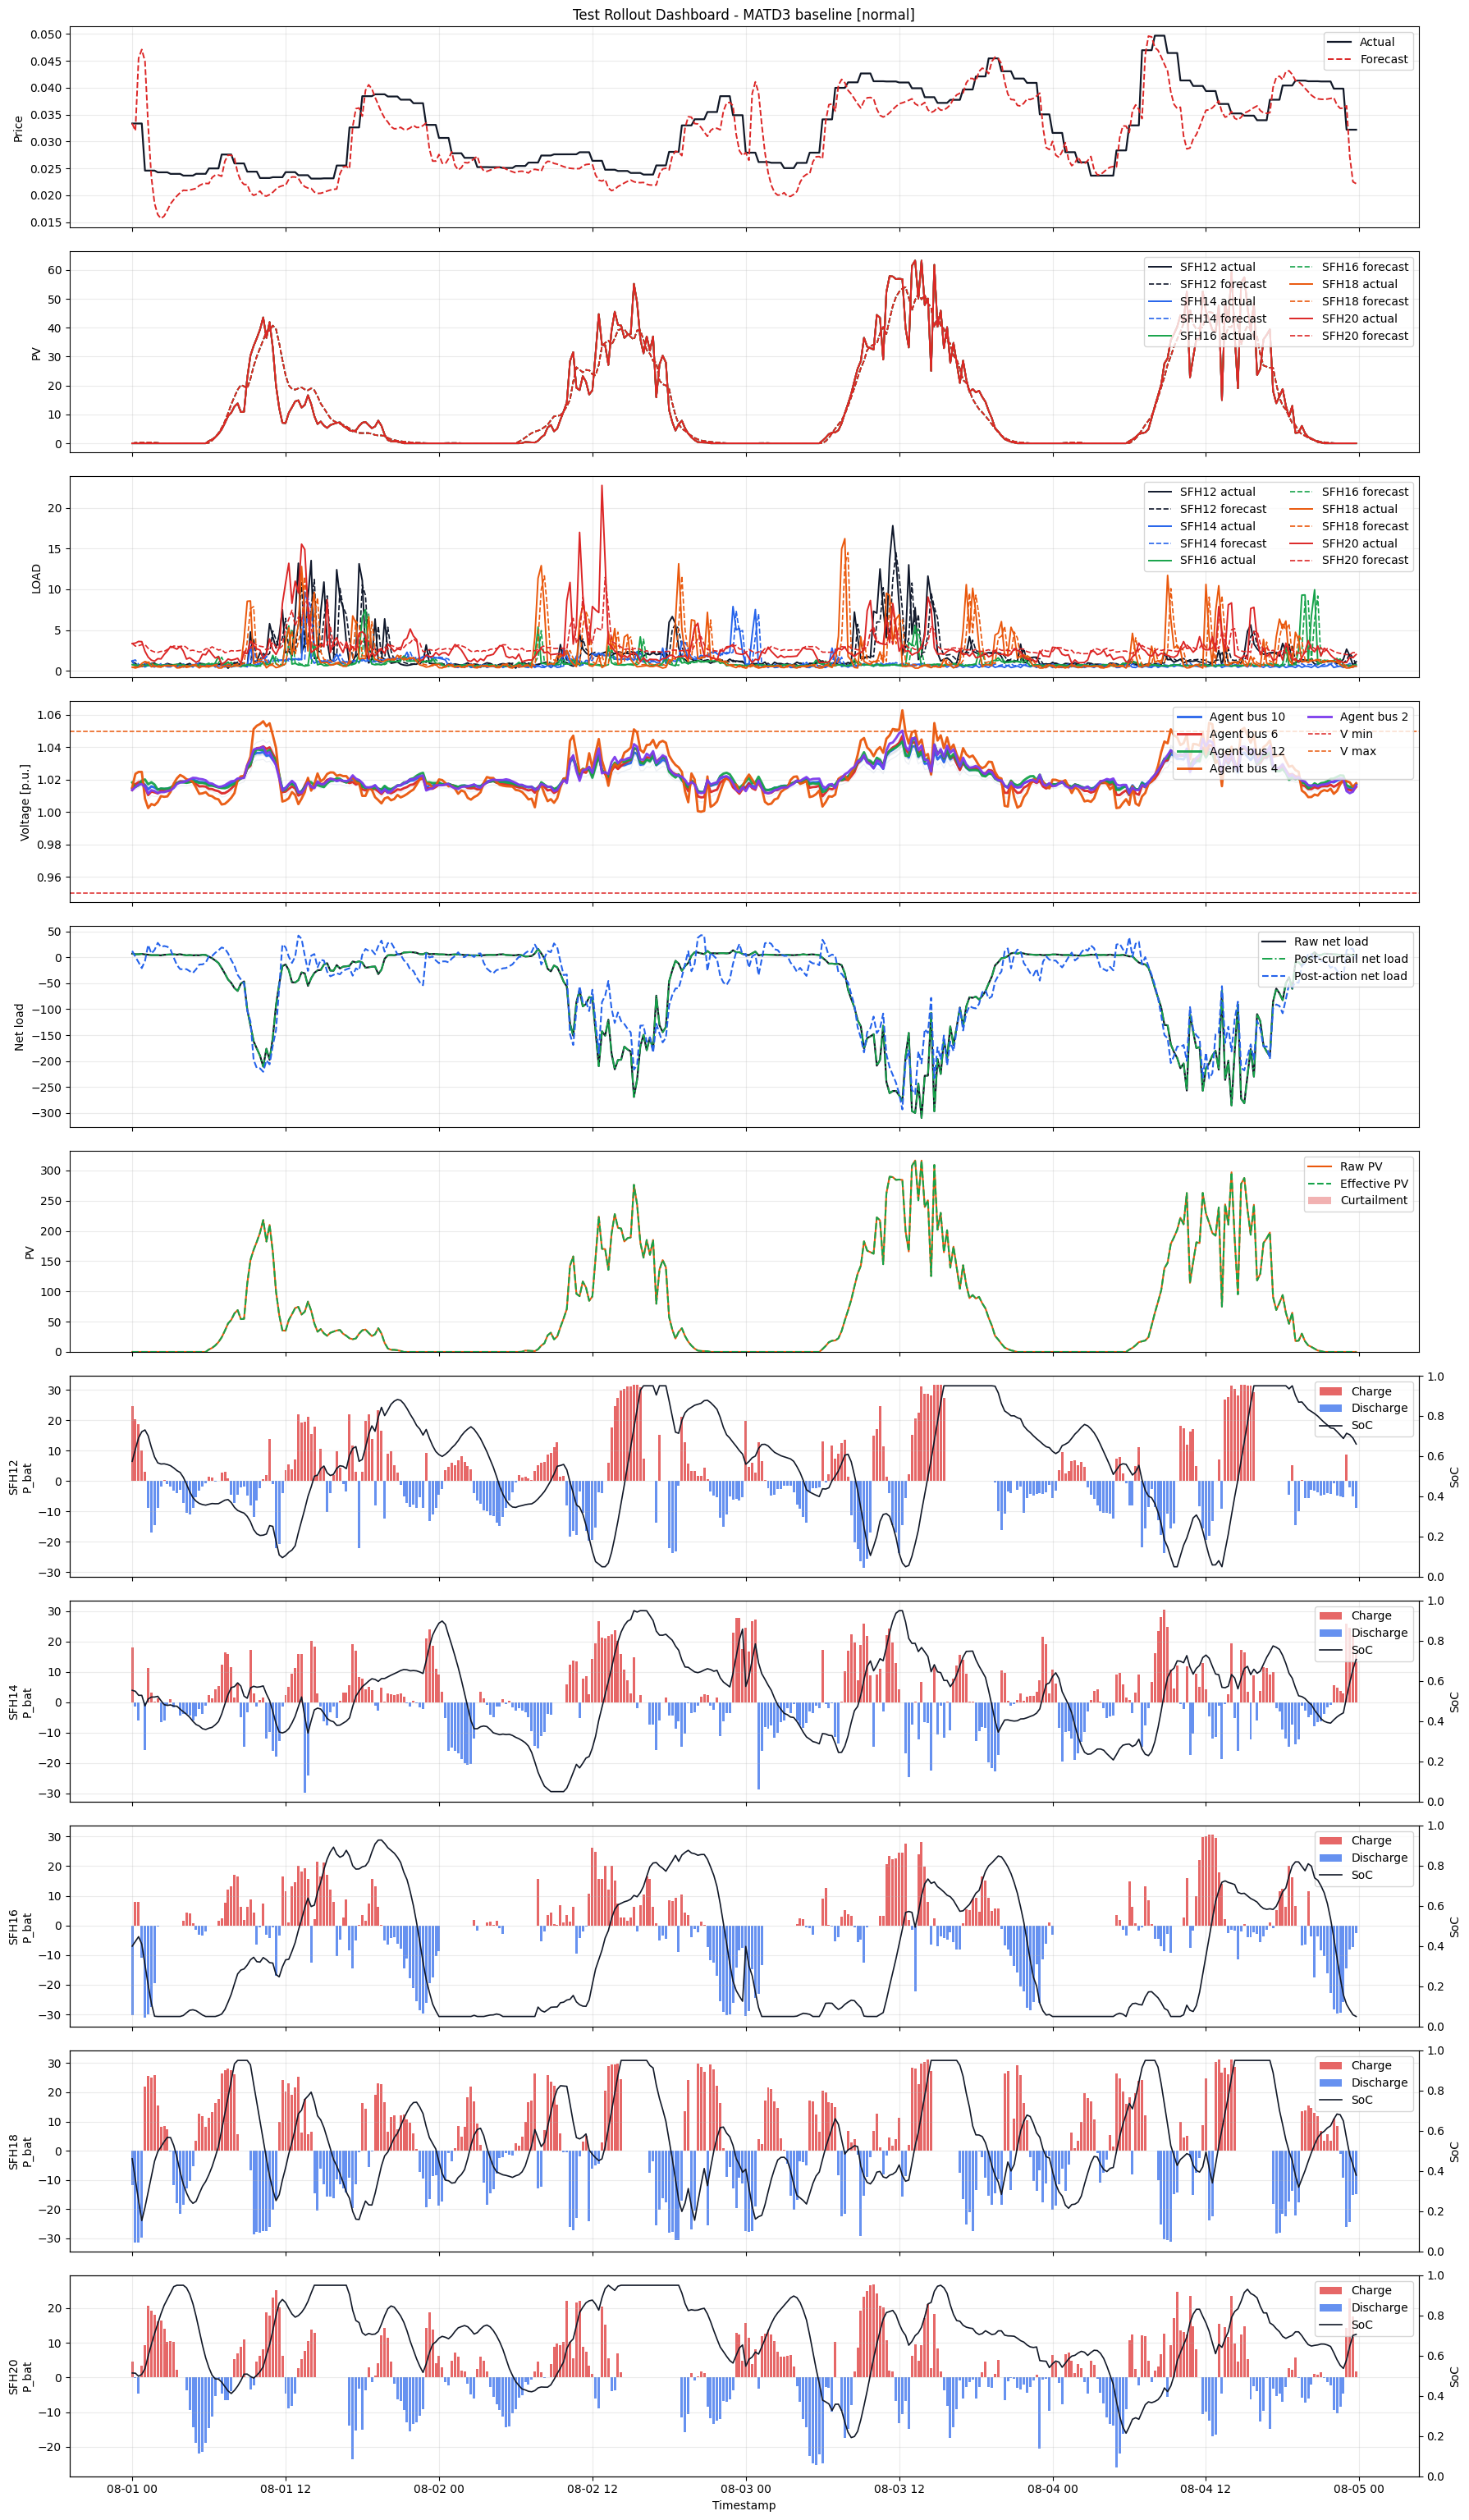

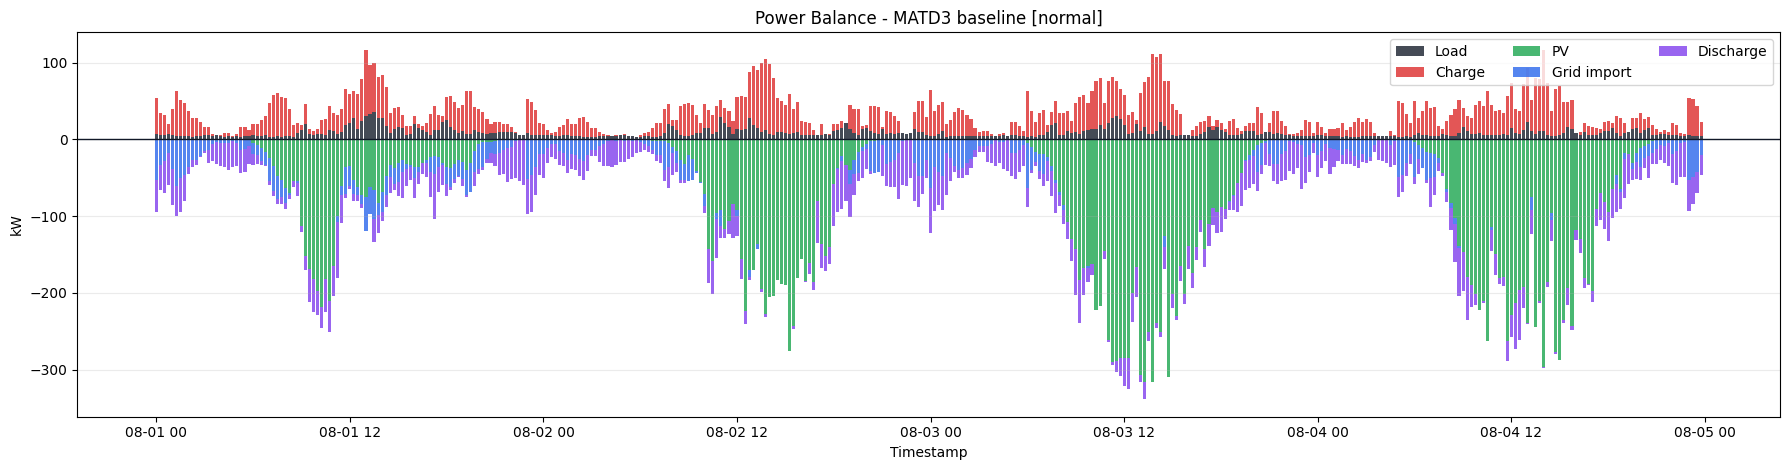

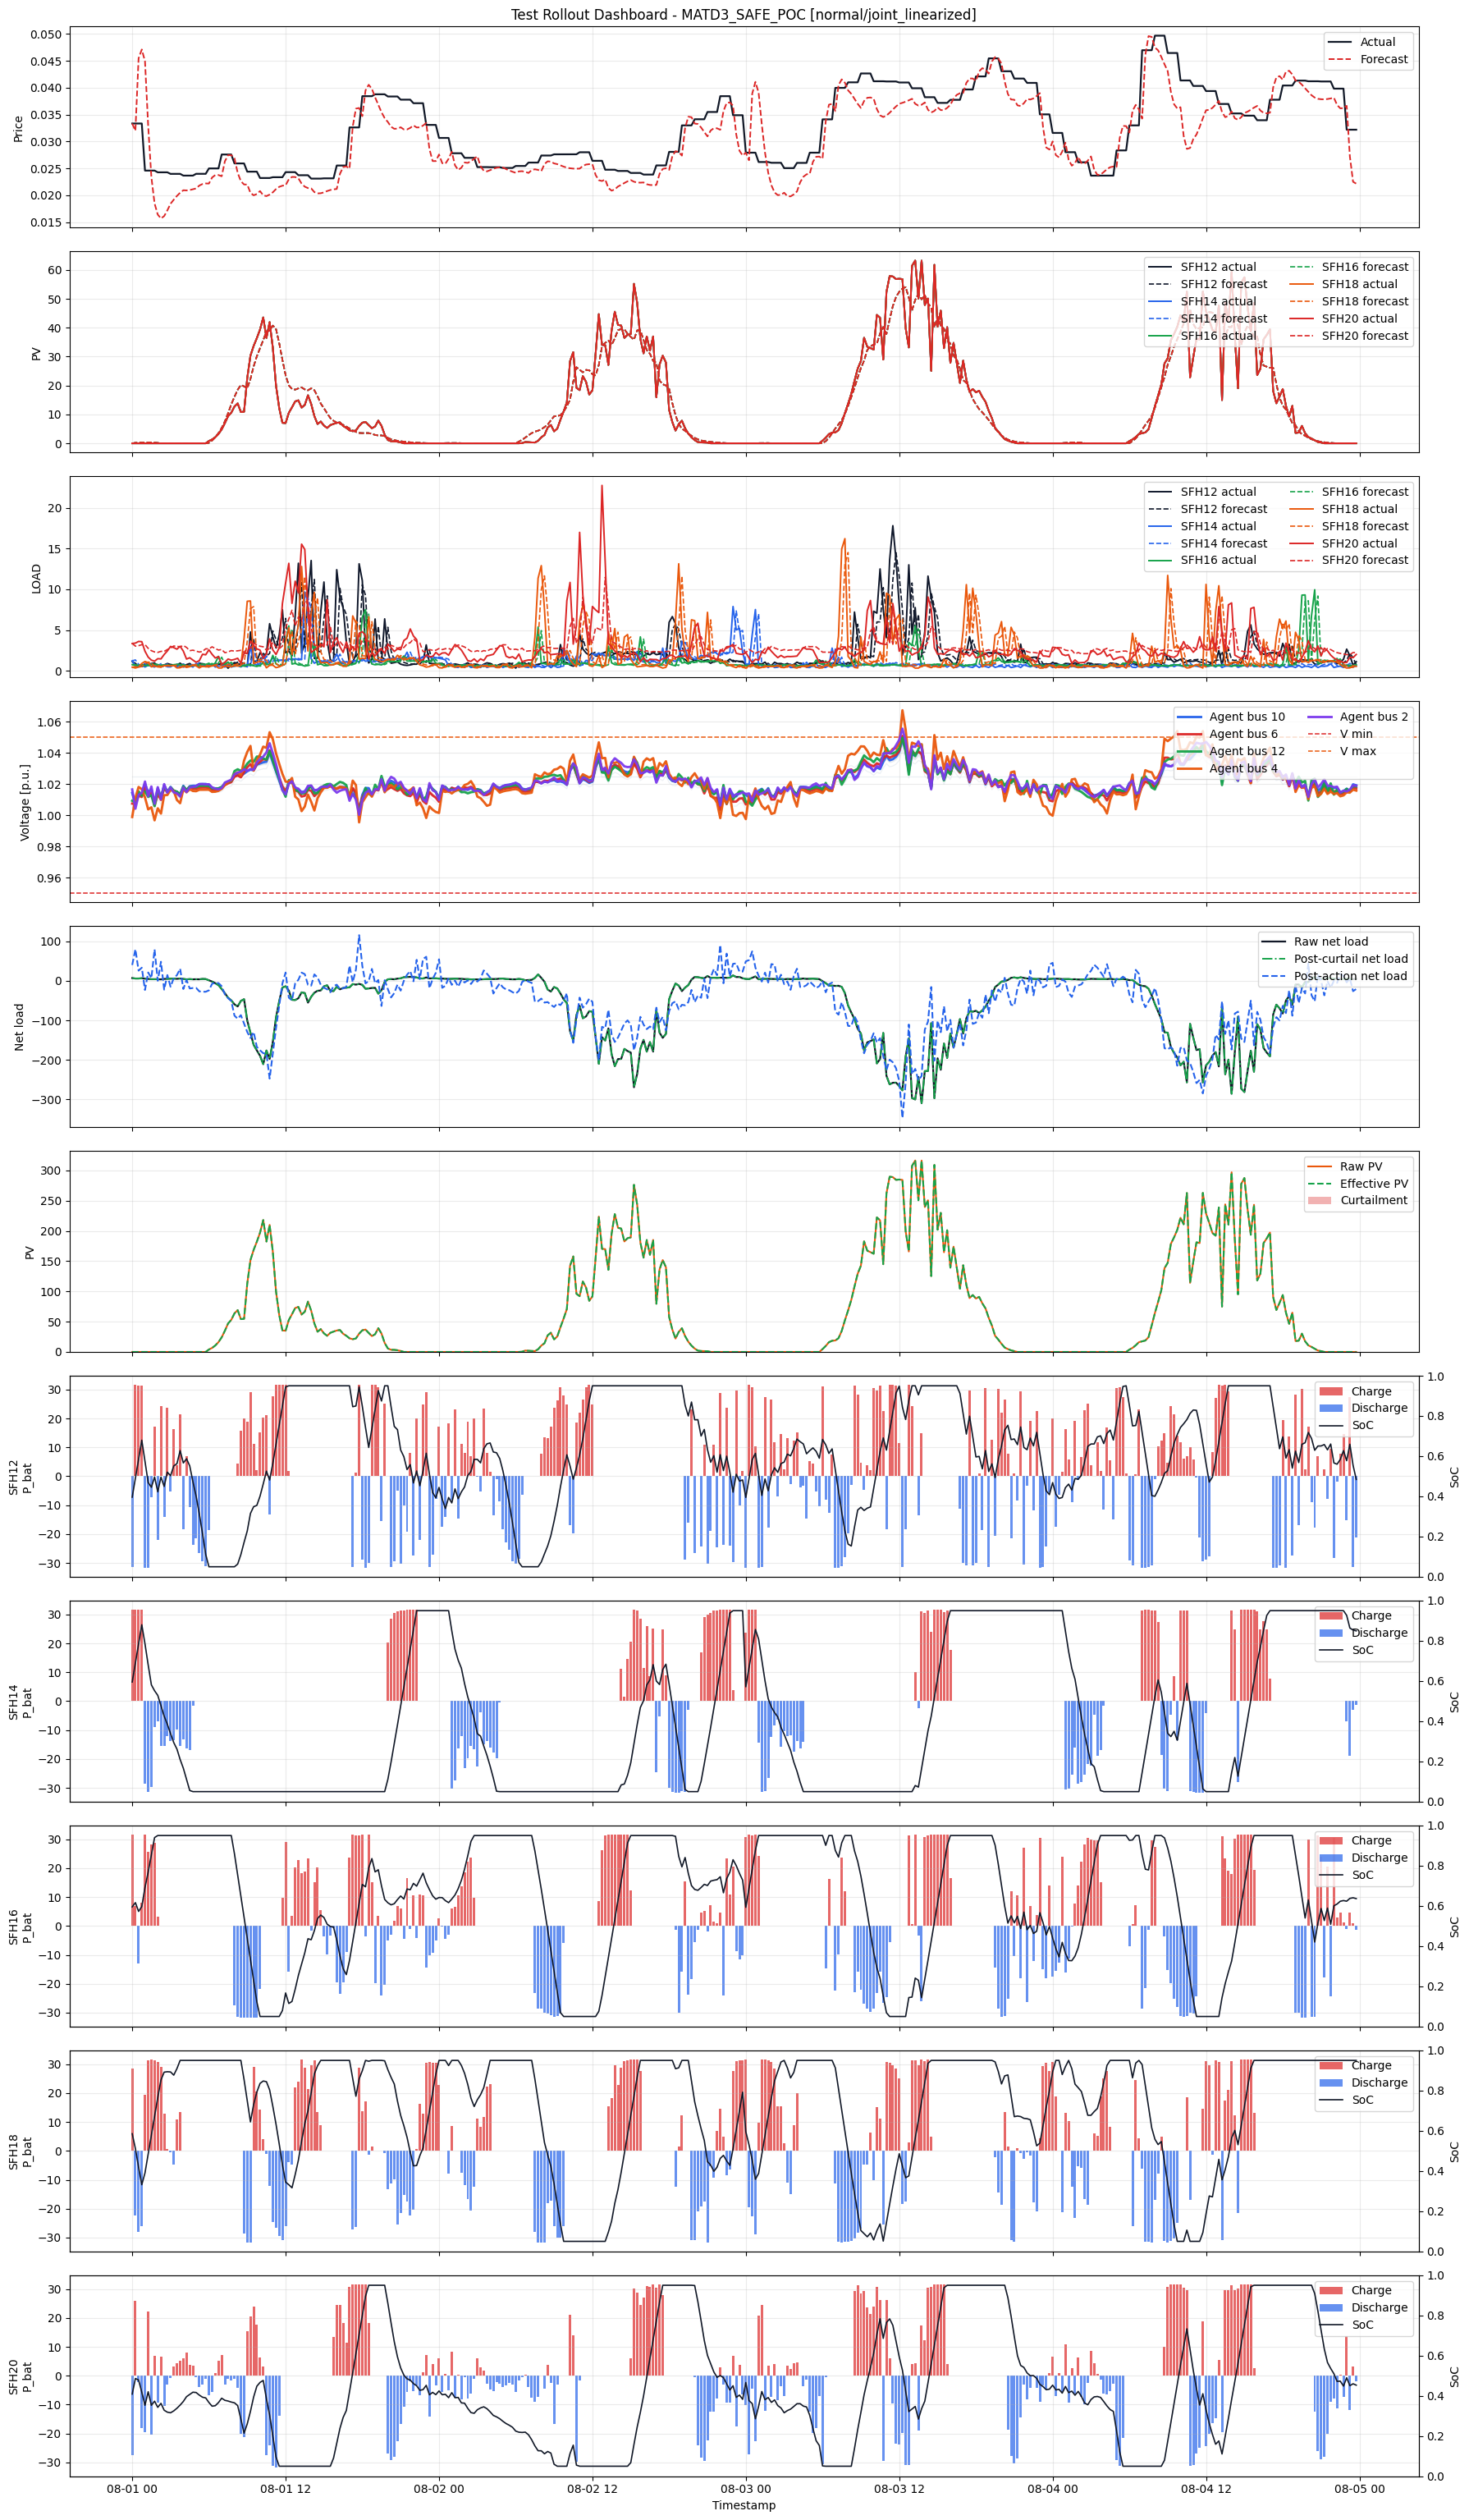

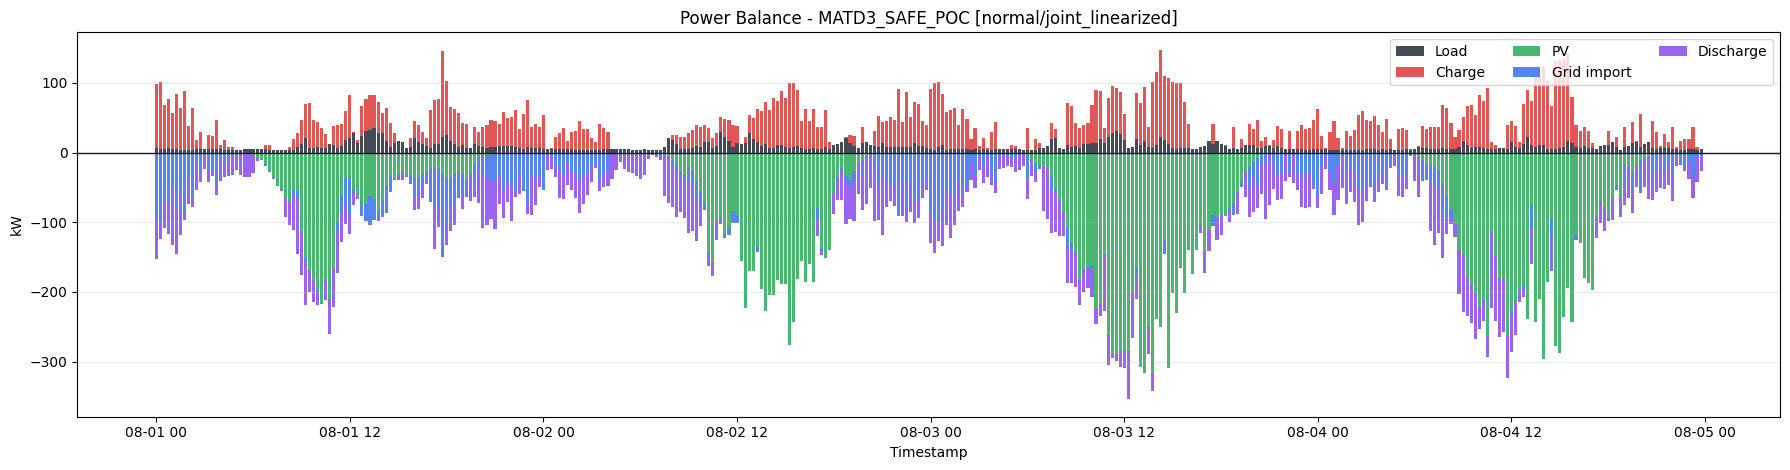

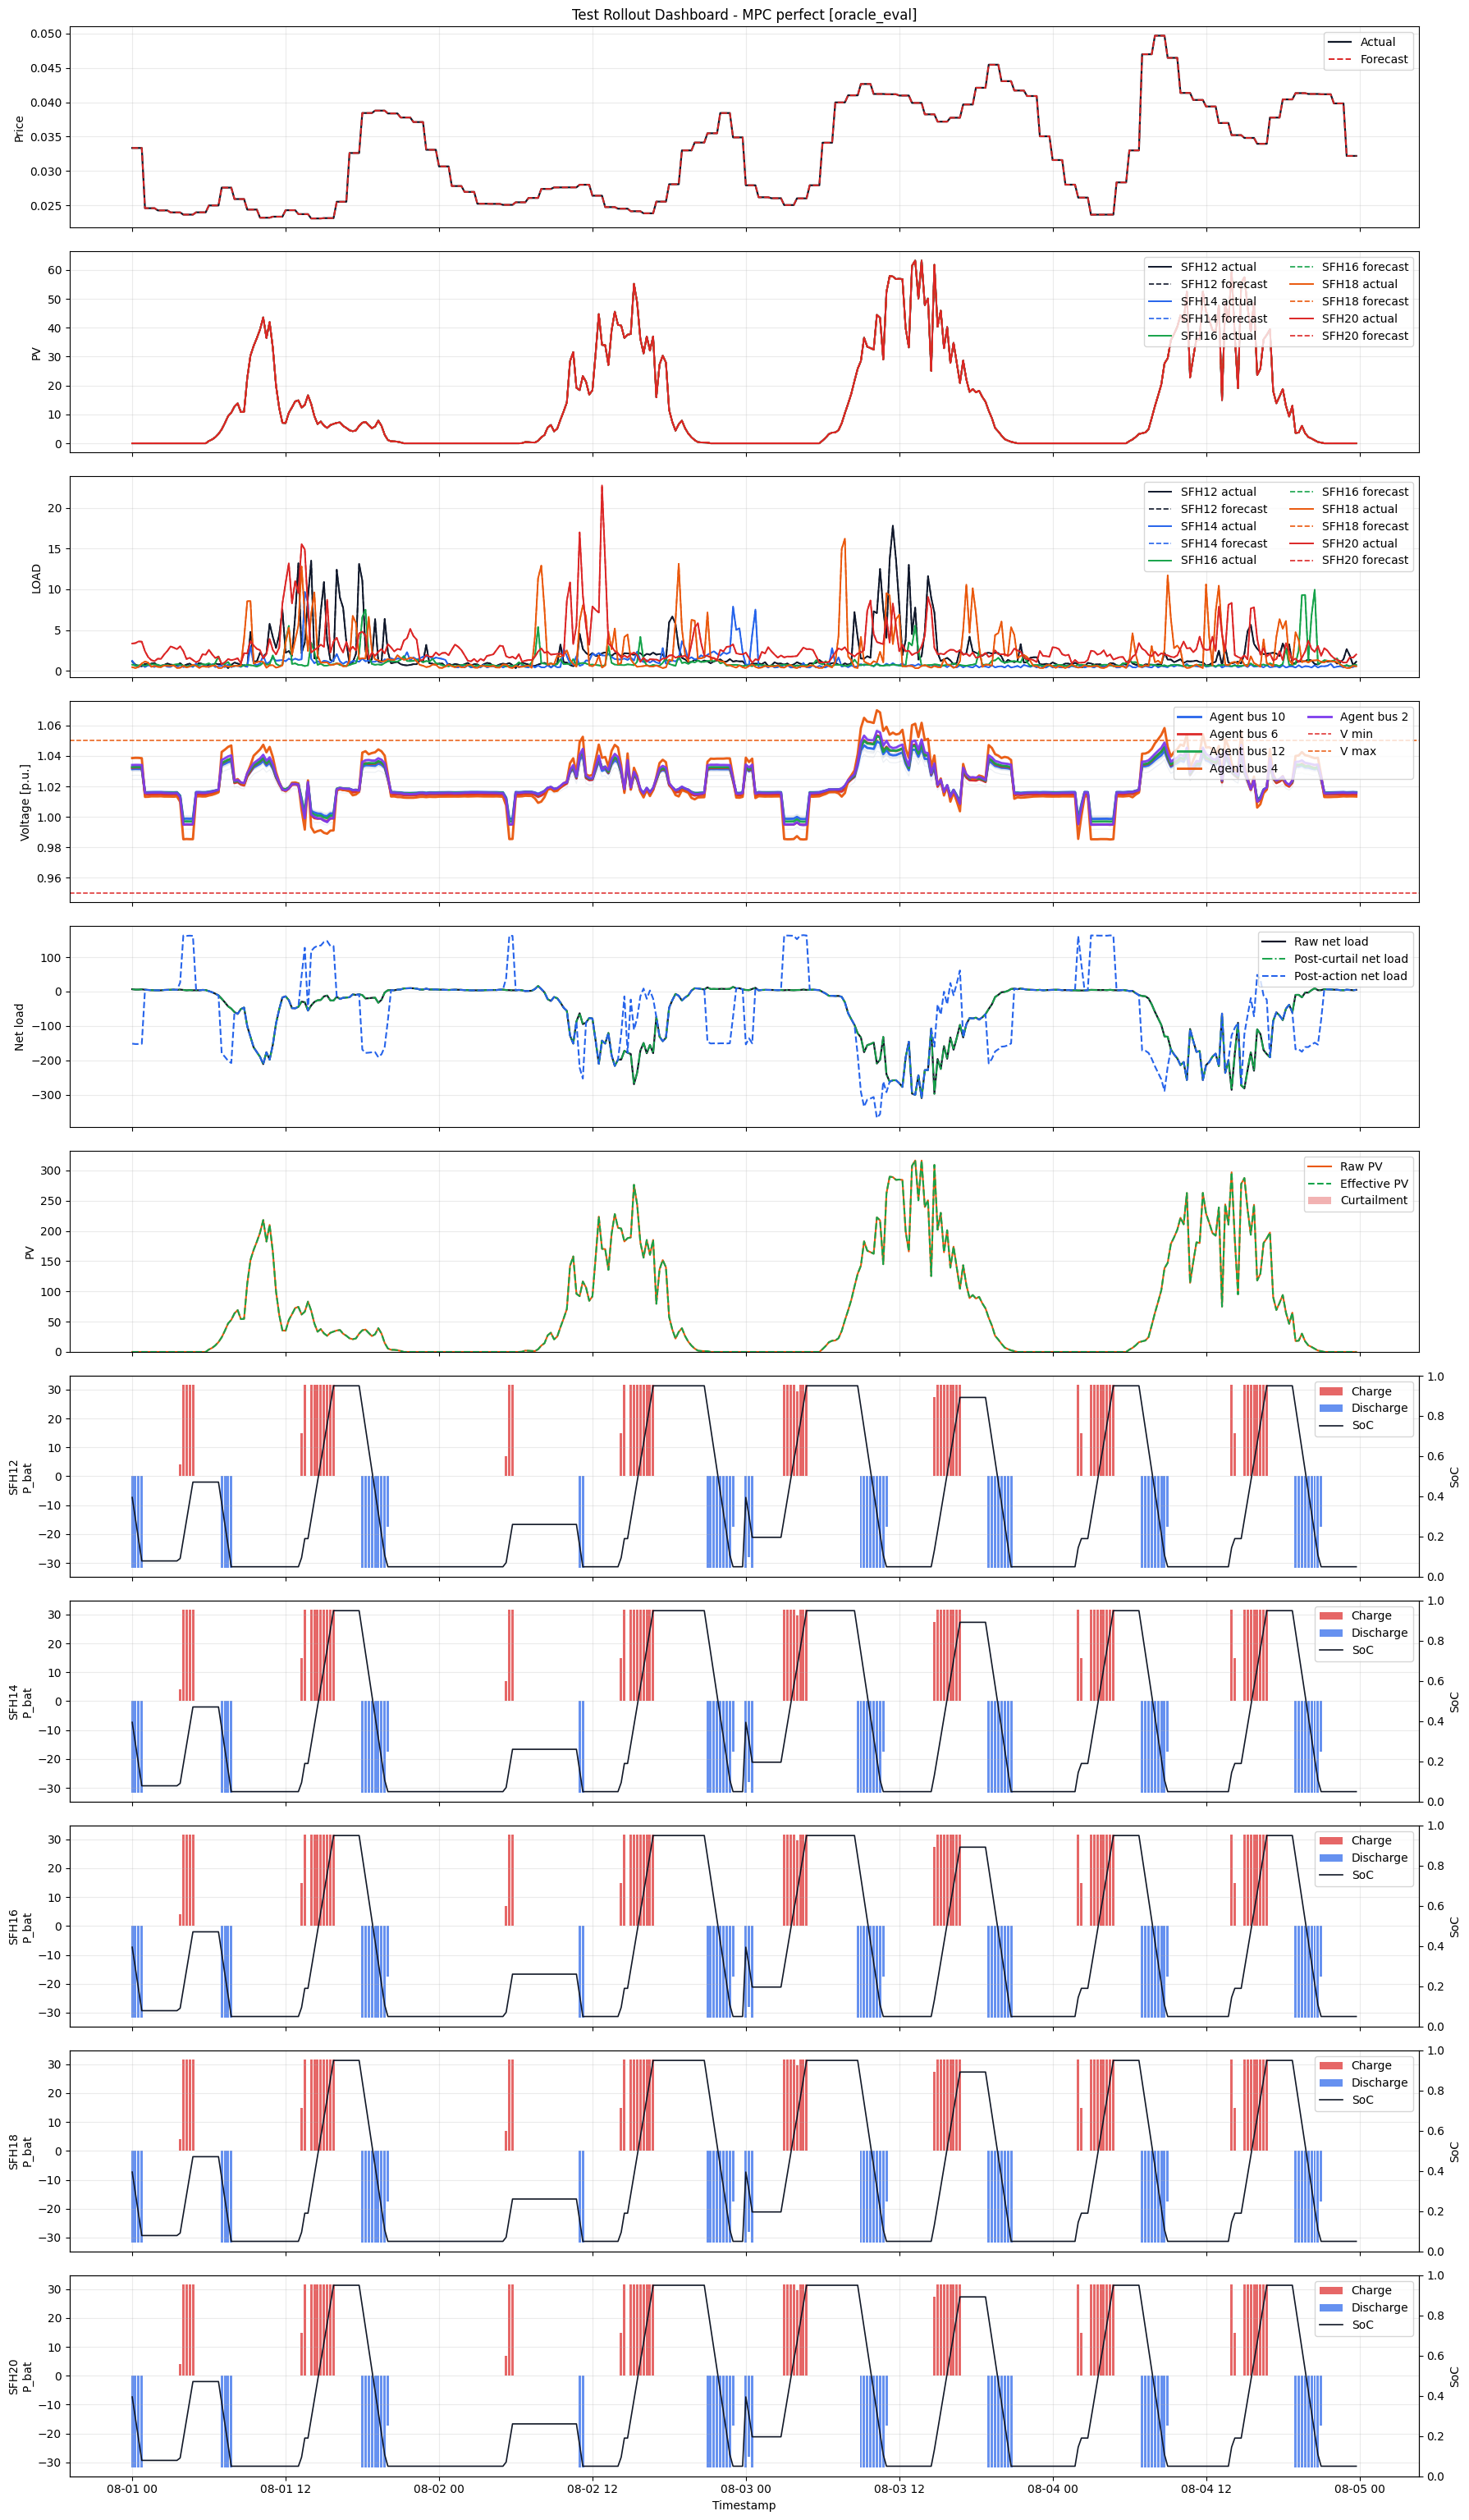

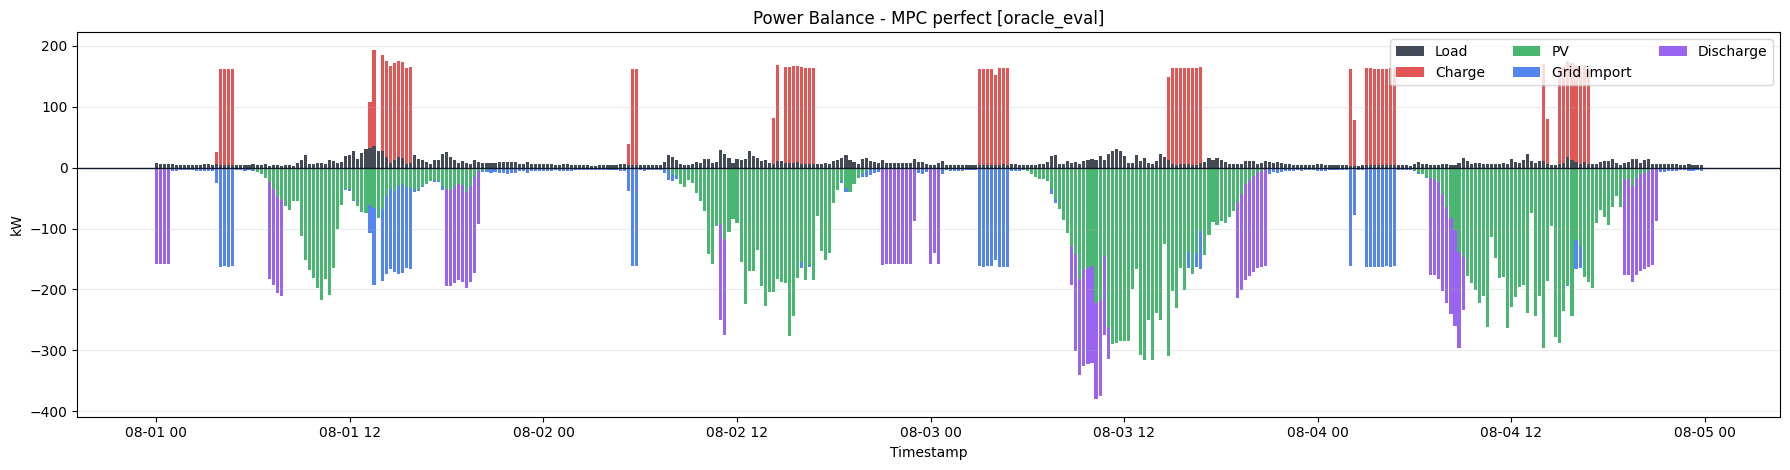

In [ ]:
if MPC_REFERENCE_ENABLED and mpc_perfect_rollout is not None:
    plot_rollout_dashboard(mpc_perfect_rollout)
    plot_power_balance_bars(mpc_perfect_rollout)
if MPC_REFERENCE_ENABLED and mpc_normal_rollout is not None:
    plot_rollout_dashboard(mpc_normal_rollout)
    plot_power_balance_bars(mpc_normal_rollout)
plot_rollout_dashboard(safe_rollout)
plot_power_balance_bars(safe_rollout)
plot_rollout_dashboard(baseline_rollout)
plot_power_balance_bars(baseline_rollout)

post_plot_cleanup = release_runtime_resources()
